# Conditional Diffusion for Image Colorization

In this exercise you will build a **conditional latent diffusion model** that colorizes grayscale images using a reference color image. The reference's color palette is injected via **cross-attention** — the same mechanism Stable Diffusion uses for CLIP text embeddings.

### What You'll Implement
1. 🎯 A `ReferenceEncoder` that extracts color-palette tokens from a reference image (ResNet-18 backbone)
2. 🎯 A `UNet2DConditionModel` configured for 8-channel latent input and cross-attention conditioning
3. 🎯 The training loop step that encodes the reference and passes it as `encoder_hidden_states`
4. 🎯 The DDIM sampling loop with classifier-free guidance (CFG)

### Prerequisites
- DDPM / DDIM diffusion models
- VAEs and latent space compression
- Cross-attention (Transformers)
- Basic familiarity with the `diffusers` library

### Disclaimer

What follows is quite a lengthy theory section, which we recommend you skip for the in-class exercise session, but it is there if you want to dig deeper into the math of these models later. A good chunk of it revises concepts we already introduced in week 2, while some concepts are expanded for conditioning on images, and some concepts are new.

Good luck!

---
## 1. Diffusion Refresher: Forward Process

### The core idea

A diffusion model works in two phases. First, the **forward process** gradually destroys an image by adding noise until nothing recognisable remains. Then, a neural network learns to **reverse** this destruction step by step. Once trained, we can start from pure noise and reverse the process to generate new images.

The forward process is *not learned* — it is a fixed, mathematical procedure that we define in advance.

### Adding noise step by step

Given a clean image $x_0$, we produce a sequence of increasingly noisy versions $x_1, x_2, \ldots, x_T$ where $T = 1000$. At each step $t$, we mix the current image with a small amount of Gaussian noise controlled by a parameter $\beta_t$:

$$q(x_t \mid x_{t-1}) = N \left(x_t;\; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\right)$$

Reading this equation piece by piece:
- $\sqrt{1 - \beta_t}\, x_{t-1}$ — we **shrink** the previous image slightly (multiply by a number just below 1)
- $\beta_t \mathbf{I}$ — we **add** fresh Gaussian noise with variance $\beta_t$
- The net effect: at each step, a little bit of signal is lost and replaced by noise

### The closed-form shortcut

Iterating through all 1000 steps would be slow. A key mathematical insight lets us jump directly from the clean image $x_0$ to any noisy version $x_t$ in a single operation.

Define:
$$\alpha_t = 1 - \beta_t, \qquad \bar{\alpha}_t = \alpha_1 \cdot \alpha_2 \cdots \alpha_t = \prod_{s=1}^{t} \alpha_s$$

$\bar{\alpha}_t$ is the **cumulative signal retention** — the fraction of the original image that survives after $t$ steps of noising. Then:

$$\boxed{x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon}, \quad \varepsilon \sim N (0, \mathbf{I})$$

Breaking this down:
- $\sqrt{\bar{\alpha}_t}\, x_0$ — the **signal term**: the original image, scaled down. At $t = 0$, $\bar{\alpha}_0 \approx 1$ so this is almost the full image. At $t = 1000$, $\bar{\alpha}_T \approx 0$ so the signal vanishes.
- $\sqrt{1 - \bar{\alpha}_t}\, \varepsilon$ — the **noise term**: random Gaussian noise, scaled up. As $t$ increases, this term dominates.
- Together: $x_t$ is always a weighted mix of signal and noise, with the balance shifting from pure signal ($t=0$) to pure noise ($t=T$).

**This is the equation we use in training** — the code calls `noise_scheduler.add_noise(x_0, noise, t)` which computes exactly this formula.

### The noise schedule

The values of $\beta_t$ (and therefore $\bar{\alpha}_t$) are determined by a **noise schedule** — a predefined curve that controls *how fast* the image is destroyed.

| Schedule | Behaviour | Problem |
|----------|-----------|---------|
| **Linear** | $\beta_t$ increases linearly from $10^{-4}$ to $0.02$ | Destroys most signal in the first ~300 steps; the remaining 700 steps are almost pure noise. The model gets few useful gradients for fine details. |
| **Cosine** (ours) | $\bar{\alpha}_t$ follows a cosine curve | Signal is preserved more evenly across all timesteps. The model sees partially-noisy images at every noise level, providing useful gradients for both coarse structure and fine details. |

We use the cosine schedule (`squaredcos_cap_v2` in the `diffusers` library) because it produces better results, especially for small images like our 64×64 inputs where fine details matter.

## 2. Diffusion Refresher: Reverse Process & Training

### The core idea

If the forward process destroys images by adding noise, the reverse process **undoes** this destruction. We train a neural network to look at a noisy image $x_t$ and predict what noise was added — then we subtract that noise to recover a slightly cleaner image $x_{t-1}$.

### What the network sees and predicts

At each training step, the network $\varepsilon_\theta$ receives two inputs:
1. A **noisy image** $x_t$ — a blend of signal and noise (from the forward process)
2. The **timestep** $t$ — telling the network how noisy the image is (so it knows how aggressively to denoise)

It outputs a **predicted noise** $\hat{\varepsilon}$ — its best guess of the Gaussian noise $\varepsilon$ that was mixed into $x_0$ to produce $x_t$.

### Why predict noise instead of the clean image?

We *could* train the network to directly predict $x_0$ from $x_t$, but predicting the noise turns out to be simpler and more stable:
- The noise $\varepsilon$ is always drawn from a standard Gaussian $N (0, \mathbf{I})$ — it has a consistent, well-behaved distribution regardless of what the image looks like
- The clean image $x_0$ varies enormously (cats, dogs, landscapes…), making it a harder regression target
- Empirically, noise prediction (called **$\varepsilon$-prediction**) converges faster and produces higher-quality samples

### The training loss

$$\boxed{\mathcal{L} = \mathbb{E}_{x_0,\, \varepsilon \sim N (0,\mathbf{I}),\, t \sim \text{Uniform}(1,T)} \left[\| \varepsilon - \varepsilon_\theta(x_t, t) \|^2 \right]}$$

In plain English:
1. Pick a random training image $x_0$
2. Pick a random timestep $t$ (anywhere from 1 to 1000)
3. Sample random noise $\varepsilon$
4. Create the noisy image: $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon$
5. Ask the network to predict the noise: $\hat{\varepsilon} = \varepsilon_\theta(x_t, t)$
6. Compute the MSE between the real noise $\varepsilon$ and the prediction $\hat{\varepsilon}$

That's it — a simple regression loss. Repeat over millions of samples, and the network learns to denoise at every noise level.

### Sampling: turning noise into images

Once trained, we generate images by starting from pure noise $x_T \sim N (0, \mathbf{I})$ and iteratively denoising:

**DDPM (Denoising Diffusion Probabilistic Models):**
- The original sampling algorithm — stochastic, follows the exact reverse of the forward Markov chain
- Requires all $T = 1000$ steps → slow (~30 seconds per image on a GPU)
- High quality, but impractical for interactive use

**DDIM (Denoising Diffusion Implicit Models):**
- A **deterministic** sampling algorithm that works with the *exact same trained model* (no retraining needed)
- Skips intermediate steps by solving the diffusion ODE directly
- Reduces sampling to 50 steps (or even 25) with minimal quality loss — **20× faster**
- Same starting noise → same output (reproducible generation)

**In this exercise we train with the DDPM loss but sample with DDIM** — getting the best of both: stable training and fast inference.

---
## 3. Conditioning Diffusion Models

### The problem: unconditional models can't be controlled

Everything in Sections 1–2 describes an **unconditional** diffusion model: it generates images from noise, but we have no way to tell it *what* to generate. The output is random.

To build useful systems (text-to-image, colourisation, inpainting), we need the model to accept an external signal $c$ and generate images that respect it. This is called **conditioning**:

$$p_\theta(x_{t-1} \mid x_t, c)$$

The denoiser now sees the noisy image $x_t$ **and** the condition $c$, and must produce output that is consistent with both.

### Mechanism 1: Channel Concatenation

The simplest approach — physically append the condition to the input:

$$\text{model input} = [x_t \;\|\; c_{\text{spatial}}] \in \mathbb{R}^{B \times (C + C') \times H \times W}$$

**How it works:** The condition (e.g. a grayscale image encoded into latent space) is concatenated along the channel dimension. The U-Net sees it as additional input channels alongside the noisy image. Convolutions process both together, so the network naturally learns to use the spatial information.

**Example in our model:** The grayscale latent $z_{\text{gray}}$ (4 channels) is concatenated with the noisy colour latent $x_t$ (4 channels), giving 8 input channels. The U-Net reads the grayscale as a structural guide — "there's an edge here, a flat region there" — and uses it to decide where to place colours.

**Strength:** Preserves perfect spatial alignment — pixel $(i, j)$ in the condition maps directly to pixel $(i, j)$ in the noisy image.

**Limitation:** The condition must have the same spatial dimensions as the input. It also tends to encode *local* information (edges, textures) rather than *global* information (overall colour palette, semantic content).

### Mechanism 2: Cross-Attention

A more flexible approach — encode the condition into a sequence of **tokens** and inject them into the U-Net via attention layers.

**Step by step:**
1. An encoder (e.g. CLIP for text, ResNet for images) converts the condition into a sequence of vectors: $c_{\text{tokens}} \in \mathbb{R}^{B \times N \times D}$ — where $N$ is the number of tokens and $D$ is the dimension of each token
2. Inside the U-Net, at each cross-attention layer:
   - The U-Net's intermediate features are reshaped into a sequence and become the **queries** (Q): *"I'm processing this spatial region — what information from the condition is relevant here?"*
   - The condition tokens become the **keys** (K) and **values** (V): *"Here are the attributes I carry (keys) and the information I provide (values)"*
   - Standard attention scores determine which condition tokens each spatial location should attend to: $\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$
3. The result is that each region of the image selectively pulls information from the most relevant parts of the condition

**Example in our model:** The reference colour image is encoded by ResNet-18 into 64 tokens. At each cross-attention layer in the U-Net, the network learns to attend from "the region that looks like sky in the grayscale" to "the blue tokens from the reference image." The attention mechanism handles this matching automatically — we don't need to tell it which reference regions correspond to which parts of the grayscale.

**Strength:** Flexible — the condition can be any modality (text, image, audio) as long as it can be encoded into tokens. No spatial alignment needed.

**Limitation:** More parameters and computation than concatenation. Learns global/semantic mappings rather than pixel-precise alignment.

### Our design: both mechanisms together

For colourisation, we need *both* kinds of information:

| What we need | Mechanism | Why this one |
|-------------|-----------|-------------|
| Spatial structure (edges, shapes) | **Channel concatenation** of the grayscale latent | The grayscale must be spatially aligned with the noisy image — pixel $(i,j)$ in the grayscale guides exactly pixel $(i,j)$ in the output |
| Colour palette (which colours to use) | **Cross-attention** from reference image tokens | The reference image shows the right colours but from a *different* viewpoint/pose. We don't want pixel alignment — we want the model to match "sky regions" to "blue tokens" regardless of position |

This dual-conditioning design mirrors Stable Diffusion, which uses channel concatenation for spatial control (e.g. ControlNet) and cross-attention for semantic control (text prompts via CLIP tokens).

### Classifier-Free Guidance (CFG)

There's one more technique we use that bridges training and inference. The idea: during training, we **randomly drop the condition** 10% of the time (replace the reference tokens with zeros). This forces the model to learn two behaviours:
- **With condition** → generate output consistent with the reference
- **Without condition** → generate a plausible output on its own (unconditional)

At inference time, we exploit both behaviours via **Classifier-Free Guidance**:

$$\hat{\varepsilon} = \varepsilon_{\text{uncond}} + s \cdot (\varepsilon_{\text{cond}} - \varepsilon_{\text{uncond}})$$

where $s$ is the **guidance scale** (we use $s = 3.0$). Intuitively:
- $\varepsilon_{\text{cond}} - \varepsilon_{\text{uncond}}$ = *"the difference the reference makes"* — what the condition adds beyond what the model would do on its own
- Multiplying by $s > 1$ **amplifies** this difference — stronger colours, more faithful to the reference
- $s = 1.0$ means no amplification; $s = 3.0$ triples the effect of the reference

You will implement both the training-time dropout (TODO 3) and the inference-time blending (TODO 4).

## 4. VAE & Latent Space Refresher

Running diffusion on full-resolution images is expensive. **Latent Diffusion Models** first compress images with a frozen VAE, then run diffusion in the smaller latent space:

$$64{\times}64{\times}3 \xrightarrow{\mathcal{E}} 8{\times}8{\times}4 \xrightarrow{\text{diffusion}} 8{\times}8{\times}4 \xrightarrow{\mathcal{D}} 64{\times}64{\times}3$$

> **Why 4 latent channels?** The 4 channels do *not* correspond to RGBA — they are learned compressed representations chosen by the VAE during pre-training. The number 4 is a design choice that balances compression ratio (48× fewer dimensions than pixel space) against reconstruction quality.

We use the pre-trained [`stabilityai/sd-vae-ft-mse`](https://huggingface.co/stabilityai/sd-vae-ft-mse) VAE (frozen). It uses a **scaling factor** of `0.18215` — latents are multiplied by this after encoding and divided before decoding. This ensures the latent distribution has roughly unit variance, which is important because the diffusion noise schedule assumes the data starts near $N (0, \mathbf{I})$.

---
## 5. Stable Diffusion Architecture & Our Approach

Stable Diffusion conditions via `encoder_hidden_states`: a tensor `(B, seq_len, dim)` of tokens that enter the U-Net through **cross-attention layers**. We replace the CLIP text encoder with a ResNet-18 image encoder — same mechanism, different modality:

| | Stable Diffusion | Our Colorization Model |
|---|---|---|
| **Condition** | Text prompt | Reference color image |
| **Encoder** | CLIP (frozen) | ResNet-18 layer2 (frozen) + linear projection |
| **Token shape** | (B, 77, 768) | (B, 64, 512) |
| **Additional input** | — | Grayscale latent (channel-concatenated) |

### Full Pipeline

```
Reference Image ──► ResNet-18 layer2 (frozen) ──► Linear proj ──► (B, 64, 512) context
                                                                         │
Grayscale ──► VAE Encoder ──► z_gray (4×8×8) ──────────────┐           │ cross-attention
                                                              │ concat    │
Color ──► VAE Encoder ──► z_color ──► add noise ──► [x_t ; z_gray] (8×8×8)
                                                              │           │
                                              UNet2DConditionModel ◄──────┘
                                                              │
                                                      ε̂ → DDIM → VAE Decode → Colorized
```

---
## 6. Setup

Run the cells below — no modifications needed. They install dependencies, import libraries, and configure the environment.

In [ ]:
#@title <🔧 Install Dependencies — Run Without Modification> {display-mode: "form"}
!pip install -q diffusers accelerate transformers lpips opencv-python-headless

In [ ]:
#@title <🔧 Imports & Device Setup — Run Without Modification> {display-mode: "form"}
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.amp import autocast
from torch.amp import GradScaler

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, DDIMScheduler
from torchvision import transforms, models
from torchvision.datasets import CIFAR10

import contextlib
import lpips
from PIL import Image
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from skimage.color import rgb2lab, lab2rgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

Using device: cuda
GPU: NVIDIA L4


---
## 7. CIFAR-10 Data Loading

We use CIFAR-10 (6 animal classes, 30K images) upscaled from 32×32 to 64×64. Each sample is a triplet:
- **Color target** — the original RGB image (reconstruction target)
- **Grayscale input** — luminance channel replicated to 3 channels (structural guide)
- **Reference image** — a *different* image from the **same class** (colour palette source)

> **Why a different image?** If the reference were the target itself, the model could learn to simply copy pixels instead of learning colour transfer. By using a *different* image from the same class, the model is forced to extract the general colour palette via cross-attention and apply it guided by the grayscale structure — which is exactly the skill we want it to learn.

Run the cells below — no modifications needed.

In [ ]:
#@title <🔧 Download CIFAR10 — Run Without Modification> {display-mode: "form"}
# ============================================================
# Download CIFAR-10 and build per-class index (animals only)
# ============================================================
DATA_DIR = "/content/cifar10"

# Download train split (50,000 images across 10 classes, 5,000 per class)
cifar_train = CIFAR10(root=DATA_DIR, train=True, download=True)

# CIFAR-10 animal classes: bird=2, cat=3, deer=4, dog=5, frog=6, horse=7
# We skip non-animals (airplane=0, automobile=1, ship=8, truck=9) because
# vehicles tend to be grey/monochrome and hurt colorization training.
ANIMAL_CLASS_INDICES = {2, 3, 4, 5, 6, 7}  # 6 classes x 5,000 = 30,000 images

# Build a dict: {class_idx (int): [PIL Image, ...]}
# cifar_train.data is a numpy array (N, 32, 32, 3); .targets is a list of ints
category_images = {}
for img_array, label in zip(cifar_train.data, cifar_train.targets):
    if label not in ANIMAL_CLASS_INDICES:
        continue
    pil_img = Image.fromarray(img_array)
    category_images.setdefault(label, []).append(pil_img)

class_names = cifar_train.classes   # ['airplane', 'automobile', 'bird', ...]
print(f"Animal classes selected:")
for idx in sorted(ANIMAL_CLASS_INDICES):
    print(f"  {class_names[idx]} (class {idx}): {len(category_images[idx])} images")
print(f"Total images: {sum(len(v) for v in category_images.values())}")

Animal classes selected:
  bird (class 2): 5000 images
  cat (class 3): 5000 images
  deer (class 4): 5000 images
  dog (class 5): 5000 images
  frog (class 6): 5000 images
  horse (class 7): 5000 images
Total images: 30000


In [ ]:
#@title <🔧 CIFAR10 Dataset Object — Run Without Modification> {display-mode: "form"}
class CIFARColorizationDataset(Dataset):
    """Dataset that returns (color, grayscale, reference) triplets from CIFAR-10 images.

    - color:     original color image upscaled to 64x64 (the target)
    - grayscale: luminance of the target, replicated to 3 channels (VAE expects 3ch)
    - reference: a different image from the same CIFAR-10 class (color palette source)

    Images are stored as PIL Images in memory (CIFAR-10 is small enough).
    """

    def __init__(self, category_images: dict, image_size: int = 64):
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # -> [-1, 1]
        ])

        # Build flat list + per-class index groups
        self.samples = []        # (PIL Image, class_list_idx)
        self.class_indices = []  # list of lists: indices into self.samples per class

        idx = 0
        for class_idx in sorted(category_images.keys()):
            pil_images = category_images[class_idx]
            group = []
            for pil_img in pil_images:
                self.samples.append((pil_img, len(self.class_indices)))
                group.append(idx)
                idx += 1
            self.class_indices.append(group)

    def __len__(self):
        return len(self.samples)

    def _to_grayscale_3ch(self, img_tensor):
        """Convert RGB tensor [-1,1] to grayscale using luminance, keep 3 channels."""
        rgb = (img_tensor + 1) / 2                                          # [0, 1]
        gray = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]           # (H, W)
        gray_3ch = gray.unsqueeze(0).repeat(3, 1, 1)                        # (3, H, W)
        return gray_3ch * 2 - 1                                             # back to [-1, 1]

    def __getitem__(self, idx):
        pil_img, class_idx = self.samples[idx]
        color = self.transform(pil_img)
        gray = self._to_grayscale_3ch(color)

        # Pick a random *different* image from the same class as the reference
        class_group = self.class_indices[class_idx]
        ref_idx = idx
        while ref_idx == idx and len(class_group) > 1:
            ref_idx = random.choice(class_group)
        ref_pil, _ = self.samples[ref_idx]
        ref = self.transform(ref_pil)

        return {"color": color, "gray": gray, "ref": ref}

Dataset size: 30000 images
Batches per epoch: 118


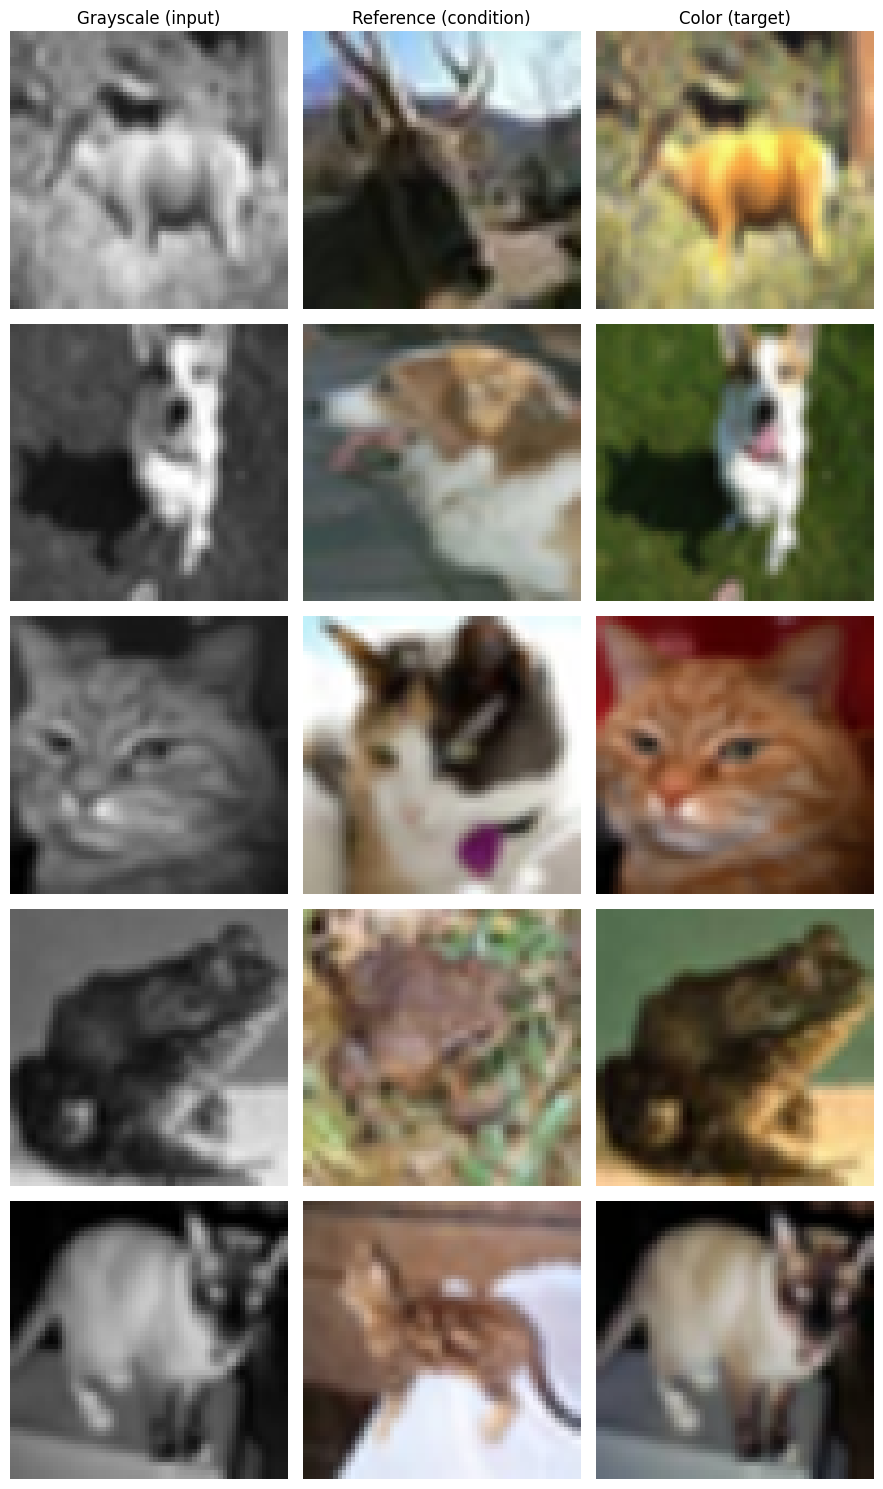

In [ ]:
#@title <🔧 Create Dataset and Dataloader — Run Without Modification> {display-mode: "form"}
# --- Create dataset and dataloader ---
dataset = CIFARColorizationDataset(category_images, image_size=64)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")

# --- Visualize sample triplets ---
def show_triplets(batch, n=5):
    """Display (grayscale, reference, color target) triplets."""
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    titles = ["Grayscale (input)", "Reference (condition)", "Color (target)"]
    for i in range(n):
        for j, key in enumerate(["gray", "ref", "color"]):
            img = batch[key][i].permute(1, 2, 0).numpy() * 0.5 + 0.5  # [-1,1] -> [0,1]
            axes[i, j].imshow(img.clip(0, 1))
            axes[i, j].set_title(titles[j] if i == 0 else "")
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

sample_batch = next(iter(dataloader))
show_triplets(sample_batch, n=5)

---
## 8. Model Definition

Our model has four components:

| Component | Role | Trainable? |
|-----------|------|------------|
| **VAE** ([`AutoencoderKL`](https://huggingface.co/docs/diffusers/api/models/autoencoderkl)) | Compress images ↔ latents | No (frozen) |
| **Reference Encoder** | Encode reference image → 64 tokens × 512 dim | Projection layer only |
| **U-Net** ([`UNet2DConditionModel`](https://huggingface.co/docs/diffusers/api/models/unet2d-cond)) | Denoise latents with cross-attention conditioning | Yes |
| **Noise Schedulers** ([`DDPMScheduler`](https://huggingface.co/docs/diffusers/api/schedulers/ddpm) / [`DDIMScheduler`](https://huggingface.co/docs/diffusers/api/schedulers/ddim)) | Manage noise schedule during training and inference | N/A |

**The VAE and ReferenceEncoder backbone are frozen** — only the U-Net and the reference projection layer are trained.

### How cross-attention works inside the U-Net

The `UNet2DConditionModel` accepts an `encoder_hidden_states` argument — a tensor of shape `(B, seq_len, dim)`. At each cross-attention block inside the U-Net:

1. The U-Net's spatial features become the **queries** (Q) — "what colour should this region have?"
2. The reference encoder tokens become the **keys** (K) and **values** (V) — "here is the colour information"
3. The attention scores decide which reference tokens are most relevant for each spatial location

This is identical to how CLIP text tokens condition Stable Diffusion — we just provide image tokens instead of text tokens.

### Why ResNet-18 layer2?

The choice of *which* ResNet layer to stop at controls the spatial granularity of the colour tokens:

| Layer | Output shape | Tokens | Trade-off |
|-------|-------------|--------|-----------|
| `layer2` (ours) | (B, 128, 8×8) | **64 tokens** of dim 128 | Fine-grained: each token corresponds to an 8×8 patch of the reference — good for localised colour correspondence |
| `layer3` | (B, 256, 4×4) | 16 tokens of dim 256 | Coarser: fewer tokens mean the model has less spatial precision to map colours to specific regions |

We use **layer2** because finer spatial resolution helps the U-Net match *which* colours from the reference belong to *which* parts of the grayscale image.

### Why the linear projection?

ResNet layer2 outputs 128-dim features, but the U-Net's cross-attention layers expect `cross_attention_dim=512`. The trainable `nn.Linear(128, 512)` bridges this gap — it projects each backbone token into the dimension the U-Net was configured to attend over. This is the same role CLIP's text projection plays in Stable Diffusion.

### A note on normalisation

Our dataset uses pixel values in `[-1, 1]`, but ResNet-18 was pre-trained on ImageNet with a different normalisation (mean `[0.485, 0.456, 0.406]`, std `[0.229, 0.224, 0.225]`). The `_normalize` method in `ReferenceEncoder` converts from our convention to ImageNet's before passing through the frozen backbone. This is provided for you — do not modify it.

In [ ]:
#@title <🔧 Load VAE and Helpers — Run Without Modification> {display-mode: "form"}
# ============================================================
# VAE: Pre-trained Stable Diffusion VAE (frozen)
# ============================================================
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

SCALING_FACTOR = vae.config.scaling_factor  # 0.18215
print(f"VAE scaling factor: {SCALING_FACTOR}")
print(f"VAE latent channels: {vae.config.latent_channels}")  # 4


def encode_to_latent(images):
    """Encode images to VAE latent space.
    Args: images (B, 3, 64, 64) in [-1, 1]
    Returns: latents (B, 4, 8, 8)
    """
    with torch.no_grad():
        latent_dist = vae.encode(images).latent_dist
        latents = latent_dist.sample() * SCALING_FACTOR
    return latents


def decode_from_latent(latents):
    """Decode latents back to image space.
    Args: latents (B, 4, 8, 8)
    Returns: images (B, 3, 64, 64) in [-1, 1]
    """
    with torch.no_grad():
        images = vae.decode(latents / SCALING_FACTOR).sample
    return images.clamp(-1, 1)

def lab_postprocess(output_tensor, gray_tensor, ref_tensor):
    """
    Replace L channel of output with input luminance,
    then normalize ab channels to match reference mean/std.
    All inputs: (1, 3, H, W) in [-1, 1]. Returns same format.
    """
    def to_numpy(t):
        return (t[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)

    out_lab  = rgb2lab(to_numpy(output_tensor))
    gray_lab = rgb2lab(to_numpy(gray_tensor))
    ref_lab  = rgb2lab(to_numpy(ref_tensor))

    # Replace luminance with ground-truth input luminance
    out_lab[:, :, 0] = gray_lab[:, :, 0]

    # Match ab statistics to reference
    for ch in [1, 2]:
        out_mean, out_std = out_lab[:, :, ch].mean(), out_lab[:, :, ch].std() + 1e-6
        ref_mean, ref_std = ref_lab[:, :, ch].mean(), ref_lab[:, :, ch].std() + 1e-6
        out_lab[:, :, ch] = (out_lab[:, :, ch] - out_mean) / out_std * ref_std + ref_mean

    result = torch.from_numpy(
        lab2rgb(out_lab.clip(-128, 128)).astype(np.float32)
    ).permute(2, 0, 1).unsqueeze(0)
    return result * 2 - 1

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


VAE scaling factor: 0.18215
VAE latent channels: 4


Input shape:   torch.Size([4, 3, 64, 64])
Latent shape:  torch.Size([4, 4, 8, 8])
Recon shape:   torch.Size([4, 3, 64, 64])


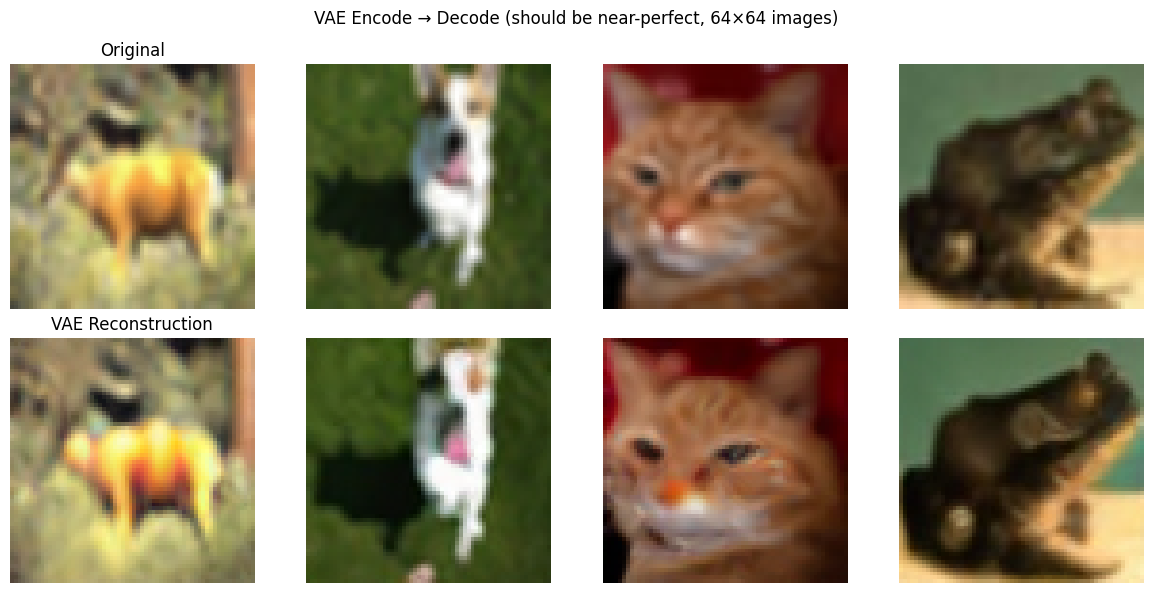

In [39]:
# ============================================================
# VAE Sanity Check: encode -> decode and compare
# ============================================================
test_imgs = sample_batch["color"][:4].to(device)
test_latents = encode_to_latent(test_imgs)
test_recon = decode_from_latent(test_latents)

print(f"Input shape:   {test_imgs.shape}")    # (4, 3, 64, 64)
print(f"Latent shape:  {test_latents.shape}")  # (4, 4, 8, 8)
print(f"Recon shape:   {test_recon.shape}")    # (4, 3, 64, 64)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    orig = test_imgs[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
    recon = test_recon[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[0, i].imshow(orig.clip(0, 1))
    axes[0, i].set_title("Original" if i == 0 else "")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon.clip(0, 1))
    axes[1, i].set_title("VAE Reconstruction" if i == 0 else "")
    axes[1, i].axis("off")
plt.suptitle("VAE Encode → Decode (should be near-perfect, 64×64 images)")
plt.tight_layout()
plt.show()

## TODO 1: Load a pretrained backbone for the reference image encoder

In [40]:
class ReferenceEncoder(nn.Module):
    """
    Encodes a reference color image into a sequence of tokens for cross-attention.

    Architecture:
        ResNet-18 (frozen, up to layer2) → spatial feature map (B, 128, 8, 8)
        → reshape to 64 tokens of 128 dim each: (B, 64, 128)
        → trainable Linear projection: (B, 64, context_dim)

    Docs: https://pytorch.org/vision/stable/models/resnet.html
    """

    def __init__(self, context_dim: int = 512):
        super().__init__()
        # 🎯 TODO: Load a pretrained ResNet-18 backbone.
        # Keep only the layers up to and including layer2.
        # Hint: models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        #       list(resnet.children())[:6] gives you up to layer2
        # Freeze all backbone parameters (no gradients).
        # Add a trainable nn.Linear(128, context_dim) as self.proj
        self.backbone = None
        self.proj = None

    def _normalize(self, x):
        # ImageNet normalisation (do not modify)
        x_01 = (x + 1) / 2
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        return (x_01 - mean) / std

    @torch.no_grad()
    def backbone_features(self, x):
        """Returns (B, 64, 128) — 64 spatial tokens from the frozen backbone."""
        # 🎯 TODO: Normalise x with self._normalize(x).
        # Pass through self.backbone → (B, 128, 8, 8).
        # Reshape to (B, 64, 128): treat each of the 8×8=64 spatial locations as a token.
        # Hint: features.reshape(B, C, H * W).permute(0, 2, 1)
        return None

    def project(self, tokens):
        """Projects (B, 64, 128) tokens to (B, 64, context_dim)."""
        return self.proj(tokens)

    def forward(self, x):
        return self.project(self.backbone_features(x))

### U-Net Configuration

We use [`UNet2DConditionModel`](https://huggingface.co/docs/diffusers/api/models/unet2d-cond) from `diffusers`. Key parameters to configure:

| Parameter | Value | Why |
|-----------|-------|-----|
| `in_channels` | **8** | 4 channels from the noisy colour latent + 4 from the grayscale latent (concatenated) |
| `out_channels` | **4** | Predicted noise $\hat{\varepsilon}$ in latent space |
| `sample_size` | **8** | 8×8 spatial latent (64px images with 8× VAE compression) |
| `cross_attention_dim` | **512** | Must match `ReferenceEncoder` output dim (128 → 512 projection) |
| `block_out_channels` | `(256, 512, 768)` | Channel widths at each resolution level |
| `layers_per_block` | **2** | Number of ResNet blocks per level |

**Block types:** `DownBlock2D` at the first level (no attention), then `CrossAttnDownBlock2D` at lower resolutions where reference colours are injected.

> **Why no attention at 8×8?** At the highest resolution, features are primarily spatial/structural — edges, shapes, boundaries from the grayscale. Cross-attention is more effective at lower resolutions (4×4, 2×2) where features become more semantic and abstract, making it easier for the model to match "this region looks like sky" to "sky-coloured reference tokens."

#### Channel flow through the U-Net

```
Input (8ch, 8×8)
  ├── DownBlock2D:          256ch, 8×8  — no attention (structural features only)
  ├── CrossAttnDownBlock2D: 512ch, 4×4  ← cross-attention with reference tokens
  ├── CrossAttnDownBlock2D: 768ch, 2×2  ← cross-attention with reference tokens
  │
  ├── Mid Block:            768ch, 2×2  (self-attn + cross-attn + ResBlocks)
  │
  ├── CrossAttnUpBlock2D:   768ch, 2×2  ← cross-attention + skip connection
  ├── CrossAttnUpBlock2D:   512ch, 4×4  ← cross-attention + skip connection
  └── UpBlock2D:            256ch, 8×8  + skip connection
Output (4ch, 8×8)
```

## TODO 2: Build the cross-attention-based UNet

In [41]:
# ============================================================
# Reference Encoder instantiation
# ============================================================
ref_encoder = ReferenceEncoder(context_dim=512).to(device)

# ============================================================
# U-Net — TODO 2
# ============================================================
# 🎯 TODO: Instantiate a UNet2DConditionModel from diffusers.
#
# Use these exact parameters:
#   sample_size        = 8
#   in_channels        = 8       (4 noisy colour + 4 grayscale)
#   out_channels       = 4       (predicted noise)
#   layers_per_block   = 2
#   block_out_channels = (256, 512, 768)
#   cross_attention_dim = 512    (must match ReferenceEncoder)
#   down_block_types   = ("DownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D")
#   up_block_types     = ("CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "UpBlock2D")
#
# Docs: https://huggingface.co/docs/diffusers/api/models/unet2d-cond
unet = None

if unet is not None:
    unet = unet.to(device)
    print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}")
    trainable_params = (
        list(unet.parameters())
        + list(ref_encoder.proj.parameters())
    )
    total_trainable = sum(p.numel() for p in trainable_params if p.requires_grad)
    print(f"Total trainable parameters: {total_trainable:,}")
else:
    print("Complete TODO 2 to instantiate the U-Net.")

U-Net parameters: 256,310,788
Total trainable parameters: 256,376,836


In [42]:
# ============================================================
# Noise Schedulers  (cosine schedule — better SNR at low timesteps)
# ============================================================
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="epsilon",
)

ddim_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
    prediction_type="epsilon",
)

# ============================================================
# Shape test: verify everything connects correctly
# ============================================================
if unet is not None:
    trainable_params = (
        list(unet.parameters())
        + list(ref_encoder.proj.parameters())
    )
    total_trainable = sum(p.numel() for p in trainable_params if p.requires_grad)
    print(f"Total trainable parameters: {total_trainable:,}")

    with torch.no_grad():
        dummy_x   = torch.randn(2, 8, 8, 8, device=device)
        dummy_t   = torch.randint(0, 1000, (2,), device=device)
        dummy_ctx = torch.randn(2, 64, 512, device=device)
        dummy_out = unet(dummy_x, dummy_t, encoder_hidden_states=dummy_ctx).sample
        assert dummy_out.shape == (2, 4, 8, 8), f"Unexpected shape: {dummy_out.shape}"
        print(f"Shape test passed: input {dummy_x.shape} -> output {dummy_out.shape}")
else:
    print("Skipping shape test — complete TODO 2 first.")

Total trainable parameters: 256,376,836
Shape test passed: input torch.Size([2, 8, 8, 8]) -> output torch.Size([2, 4, 8, 8])


### EMA (Exponential Moving Average)

During training, model weights fluctuate from step to step as the optimiser chases the loss. **EMA** maintains a smoothed copy of the weights by computing a running average:

$$\theta_{\text{EMA}} \leftarrow \alpha \cdot \theta_{\text{EMA}} + (1 - \alpha) \cdot \theta_{\text{current}}$$

where $\alpha$ (the decay, e.g. 0.9999) controls how much history to keep. The EMA weights change slowly and tend to sit in flatter regions of the loss landscape, which produces **higher-quality outputs at inference** — essentially for free, since no extra training is needed.

At inference time we temporarily swap in the EMA weights; during training we continue updating the regular weights as normal.

In [43]:
# ============================================================
# EMA (Exponential Moving Average) — inspired by powerful-attention repo
#
# Maintains a smoothed copy of model weights that typically produces
# better inference quality than raw trained weights with no extra training cost.
# Decay=0.9999 is appropriate for ~100 epochs x ~1563 steps (~156K steps total).
# For shorter runs (e.g. 10 epochs), consider decay=0.999.
# ============================================================

class EMAModel:
    """Lightweight EMA wrapper around a single nn.Module.

    After each optimizer step, call ema.step(model) to update the shadow weights.
    At inference, call ema.copy_to(model) to swap in the smoothed weights,
    then ema.restore(model, backup) to restore the originals.

    Shadow weights are kept ON GPU to avoid costly GPU→CPU sync at every step.
    """

    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.decay = decay
        # Store EMA weights on the same device as the model (GPU) to avoid sync stalls
        self.shadow = {
            name: param.data.clone()
            for name, param in model.named_parameters()
            if param.requires_grad
        }

    @torch.no_grad()
    def step(self, model: nn.Module):
        """Update EMA weights: shadow = decay * shadow + (1 - decay) * param."""
        for name, param in model.named_parameters():
            if name in self.shadow:
                self.shadow[name].mul_(self.decay).add_(
                    param.data, alpha=1.0 - self.decay
                )

    def copy_to(self, model: nn.Module):
        """Overwrite model parameters with the EMA shadow weights (for inference)."""
        for name, param in model.named_parameters():
            if name in self.shadow:
                param.data.copy_(self.shadow[name])

    def restore(self, model: nn.Module, backup: dict):
        """Restore model parameters from a backup dict."""
        for name, param in model.named_parameters():
            if name in backup:
                param.data.copy_(backup[name])


# Instantiate EMA trackers for both trainable modules
ema_unet        = EMAModel(unet,        decay=0.999)   # was 0.9999
ema_ref_encoder = EMAModel(ref_encoder, decay=0.999)   # was 0.9999
print("EMA trackers initialized for unet and ref_encoder.")

EMA trackers initialized for unet and ref_encoder.


---
## 9. Training

### Why pre-compute latents?

The VAE is frozen — it always maps the same image to the same latent. Instead of re-encoding all 30K images through the VAE every epoch, we encode them **once** before training begins and cache the results. This eliminates ~30K VAE forward passes per epoch and makes each training step much faster.

The reference images are stored as raw pixels (not pre-computed tokens) because the backbone is lightweight and we want the flexibility of dynamic augmentation in future extensions.

### Training step walkthrough

Each training step:
1. Load pre-computed latents $z_{\text{color}}$ and $z_{\text{gray}}$ from the cache
2. **🎯 Encode the reference image** → context tokens `(B, 64, 512)` using `ref_encoder`
3. Apply **CFG dropout**: with 10% probability, zero out the entire context tensor. This teaches the model to denoise *without* the reference too, which is essential for Classifier-Free Guidance at inference time (Section 10)
4. Sample noise $\varepsilon \sim N (0, \mathbf{I})$ and a random timestep $t$
5. **Forward diffusion**: $x_t = \sqrt{\bar{\alpha}_t}\, z_{\text{color}} + \sqrt{1{-}\bar{\alpha}_t}\, \varepsilon$ — this is the closed-form equation from Section 1, implemented by `noise_scheduler.add_noise()`
6. Concatenate: $[x_t \, || \, z_{\text{gray}}]$ → 8-channel input (the U-Net receives both the noisy colour latent and the structural grayscale latent)
7. **🎯 Call the U-Net** with `encoder_hidden_states=context` to predict $\hat{\varepsilon}$
8. Compute loss: MSE + 0.1 × cosine similarity loss
9. Backpropagate, clip gradients, update EMA weights

> **Note on the loss:** MSE penalises the magnitude of the error. The cosine term penalises *directional* misalignment — it ensures the predicted noise vector points in the same direction as the true noise, not just has a similar magnitude. Together, they provide both a strong learning signal and early training stability.

## TODO 3: Complete the training loop

In [44]:
# @title 🔧 Pre-compute VAE Latents — Run Without Modification
# ============================================================
# Pre-compute VAE latents ONLY
# (backbone tokens are now computed dynamically during training)
# ============================================================
print("Pre-computing VAE latents for all images...")

all_color_latents = []
all_gray_latents  = []
all_ref_images    = []   # raw reference pixel images, NOT pre-computed tokens

precompute_loader = DataLoader(
    dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True
)

for batch in tqdm(precompute_loader, desc="Encoding"):
    color_latent = encode_to_latent(batch["color"].to(device))   # (B, 4, 8, 8)
    gray_latent  = encode_to_latent(batch["gray"].to(device))    # (B, 4, 8, 8)

    all_color_latents.append(color_latent.cpu())
    all_gray_latents.append(gray_latent.cpu())
    all_ref_images.append(batch["ref"].cpu())                    # (B, 3, 64, 64) raw pixels

all_color_latents = torch.cat(all_color_latents, dim=0)
all_gray_latents  = torch.cat(all_gray_latents,  dim=0)
all_ref_images    = torch.cat(all_ref_images,    dim=0)

print(f"Color latents:  {all_color_latents.shape}")   # (N, 4, 8, 8)
print(f"Gray latents:   {all_gray_latents.shape}")    # (N, 4, 8, 8)
print(f"Ref images:     {all_ref_images.shape}")      # (N, 3, 64, 64)

class LatentDataset(Dataset):
    def __init__(self, color_latents, gray_latents, ref_images):
        self.color_latents = color_latents
        self.gray_latents  = gray_latents
        self.ref_images    = ref_images

    def __len__(self):
        return len(self.color_latents)

    def __getitem__(self, idx):
        return (
            self.color_latents[idx],
            self.gray_latents[idx],
            self.ref_images[idx],    # (3, 64, 64) — raw pixels for dynamic encoding
        )

latent_dataset = LatentDataset(all_color_latents, all_gray_latents, all_ref_images)
latent_loader  = DataLoader(
    latent_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True
)
print(f"\nLatent dataloader ready: {len(latent_loader)} batches/epoch")

Pre-computing VAE latents for all images...


Encoding:   0%|          | 0/118 [00:00<?, ?it/s]

Color latents:  torch.Size([30000, 4, 8, 8])
Gray latents:   torch.Size([30000, 4, 8, 8])
Ref images:     torch.Size([30000, 3, 64, 64])

Latent dataloader ready: 118 batches/epoch


Epoch   1/100 | Loss: 0.1628 | LR: 2.00e-04
Epoch  10/100 | Loss: 0.1498 | LR: 1.95e-04
Epoch  20/100 | Loss: 0.1455 | LR: 1.81e-04


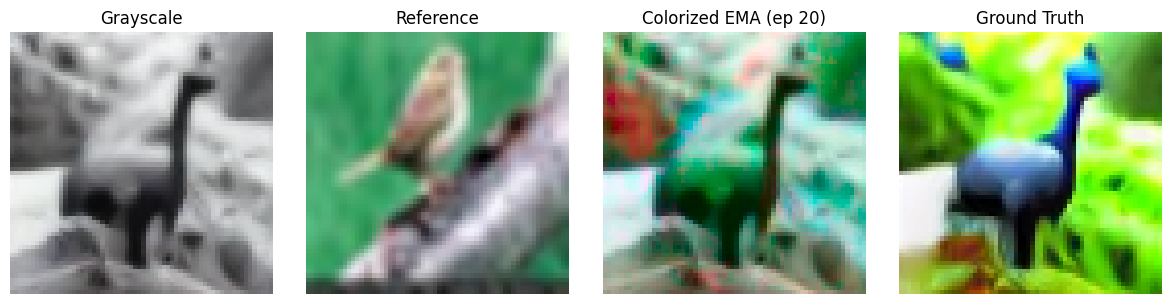

  Checkpoint saved.
Epoch  30/100 | Loss: 0.1386 | LR: 1.59e-04
Epoch  40/100 | Loss: 0.1360 | LR: 1.31e-04


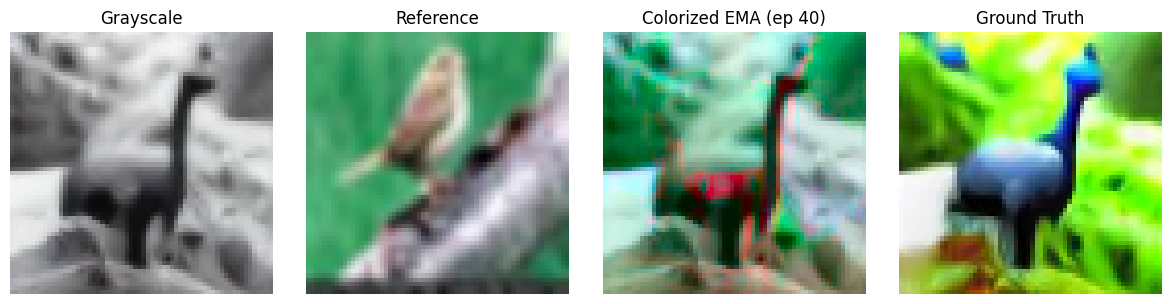

Epoch  50/100 | Loss: 0.1303 | LR: 1.00e-04
  Checkpoint saved.
Epoch  60/100 | Loss: 0.1233 | LR: 6.91e-05


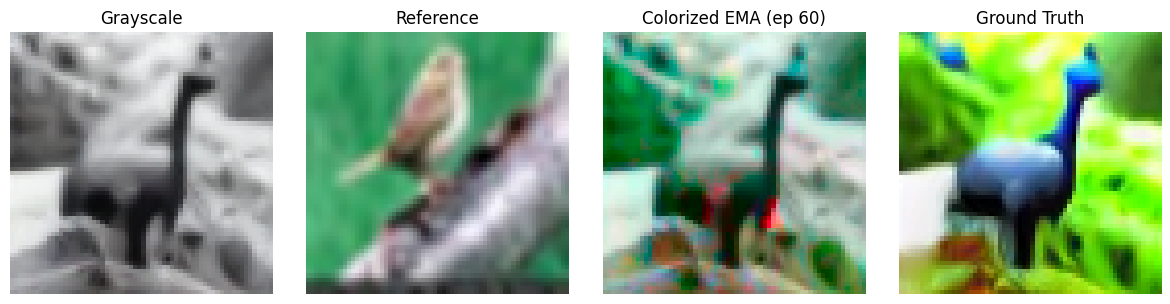

Epoch  70/100 | Loss: 0.1127 | LR: 4.12e-05
  Checkpoint saved.
Epoch  80/100 | Loss: 0.1016 | LR: 1.91e-05


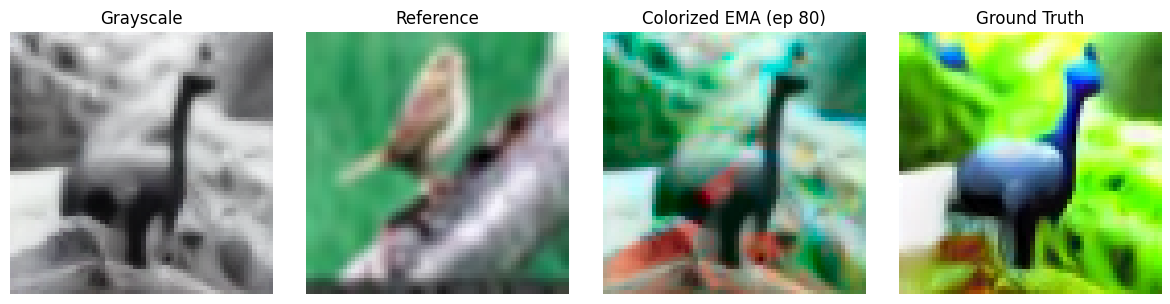

Epoch  90/100 | Loss: 0.0953 | LR: 4.89e-06
Epoch 100/100 | Loss: 0.0951 | LR: 0.00e+00


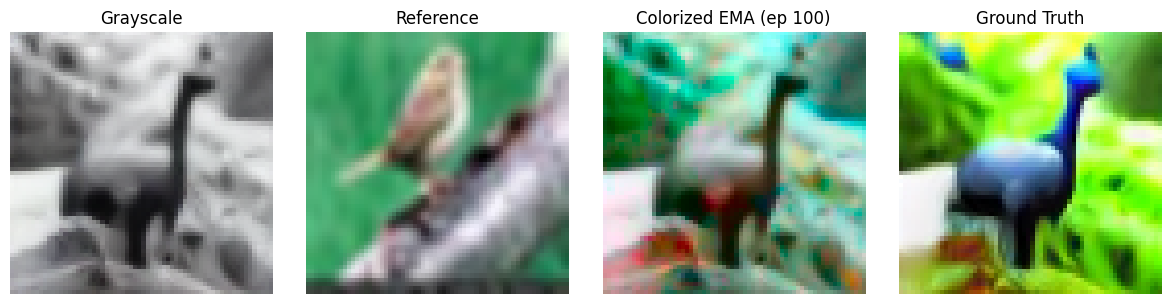

  Checkpoint saved.

Training complete!


In [46]:
# ============================================================
# Training Loop
# ============================================================
NUM_EPOCHS = 100
LR         = 2e-4
GRAD_CLIP  = 1.0

if unet is None:
    raise RuntimeError("Complete TODO 2 (unet) before running the training loop.")

trainable_params = (
    list(unet.parameters())
    + list(ref_encoder.proj.parameters())
)

optimizer    = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler       = GradScaler("cuda")

# Fixed test sample for periodic visualization
test_color_latent = all_color_latents[0:1].to(device)
test_gray_latent  = all_gray_latents[0:1].to(device)
test_ref_image    = all_ref_images[0:1].to(device)

losses = []
unet.train()
ref_encoder.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss  = 0.0
    num_batches = 0

    for color_latent, gray_latent, ref_image in latent_loader:
        color_latent = color_latent.to(device)
        gray_latent  = gray_latent.to(device)
        ref_image    = ref_image.to(device)
        B = color_latent.shape[0]

        # 🎯 TODO: Encode the reference images and build the conditioning context.
        # Step 1: Get backbone features — ref_encoder.backbone_features(ref_image)
        #         → (B, 64, 128) spatial tokens from the frozen ResNet
        # Step 2: Project to context dim — ref_encoder.proj(backbone_tokens)
        #         → (B, 64, 512)
        # Step 3: CFG dropout — with 10% probability, zero out context entirely
        #         so the model also learns to denoise unconditionally.
        #         Hint: if random.random() < 0.1: context = torch.zeros_like(context)
        context = None  # 🎯 replace with your implementation

        # ── Noise sampling and forward diffusion (provided) ──────────────────
        noise     = torch.randn_like(color_latent)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (B,), device=device
        ).long()
        noisy_latent = noise_scheduler.add_noise(color_latent, noise, timesteps)
        model_input  = torch.cat([noisy_latent, gray_latent], dim=1)  # (B, 8, 8, 8)

        # 🎯 TODO: Call the UNet to predict the noise.
        # Pass model_input, timesteps, and encoder_hidden_states=context.
        # The output is a NamedTuple — extract the noise prediction with .sample
        # Docs: https://huggingface.co/docs/diffusers/api/models/unet2d-cond
        noise_pred = None  # 🎯 replace with your implementation

        if noise_pred is None or context is None:
            print("Complete the TODOs above to begin training.")
            break

        # ── Loss, backprop, EMA (provided) ───────────────────────────────────
        optimizer.zero_grad()
        with autocast("cuda"):
            mse_loss   = F.mse_loss(noise_pred, noise)
            cos_loss   = (1 - F.cosine_similarity(noise_pred, noise, dim=1).mean())
            loss       = mse_loss + 0.1 * cos_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        ema_unet.step(unet)
        ema_ref_encoder.step(ref_encoder)

        epoch_loss  += loss.item()
        num_batches += 1

    lr_scheduler.step()
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | LR: {lr_scheduler.get_last_lr()[0]:.2e}")

    # Quick DDIM visualization every 20 epochs
    if (epoch + 1) % 20 == 0:
        unet.eval()
        ref_encoder.eval()
        with torch.no_grad():
            unet_backup = {n: p.data.clone() for n, p in unet.named_parameters() if n in ema_unet.shadow}
            ref_backup  = {n: p.data.clone() for n, p in ref_encoder.named_parameters() if n in ema_ref_encoder.shadow}
            ema_unet.copy_to(unet)
            ema_ref_encoder.copy_to(ref_encoder)

            test_backbone_tokens = ref_encoder.backbone_features(test_ref_image)
            ctx      = ref_encoder.proj(test_backbone_tokens)
            null_ctx = torch.zeros_like(ctx)
            GUIDANCE_SCALE = 3.0

            latent = torch.randn(1, 4, 8, 8, device=device)
            ddim_scheduler.set_timesteps(50)
            for t in ddim_scheduler.timesteps:
                inp = torch.cat([latent, test_gray_latent], dim=1)
                noise_pred_cond   = unet(inp, t, encoder_hidden_states=ctx).sample
                noise_pred_uncond = unet(inp, t, encoder_hidden_states=null_ctx).sample
                noise_pred_vis = noise_pred_uncond + GUIDANCE_SCALE * (noise_pred_cond - noise_pred_uncond)
                latent = ddim_scheduler.step(noise_pred_vis, t, latent).prev_sample

            preview_raw = decode_from_latent(latent)
            preview = lab_postprocess(preview_raw, decode_from_latent(test_gray_latent), test_ref_image)

            ema_unet.restore(unet, unet_backup)
            ema_ref_encoder.restore(ref_encoder, ref_backup)

        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        gt = decode_from_latent(test_color_latent)
        ref_vis = (test_ref_image[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        for ax, img, title in zip(axes,
            [decode_from_latent(test_gray_latent), ref_vis, preview, gt],
            ["Grayscale", "Reference", f"Colorized EMA (ep {epoch+1})", "Ground Truth"]):
            if isinstance(img, torch.Tensor):
                img = (img[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
        unet.train()
        ref_encoder.train()

    if (epoch + 1) % 25 == 0:
        torch.save({
            "epoch":           epoch,
            "unet":            unet.state_dict(),
            "ref_encoder":     ref_encoder.state_dict(),
            "ema_unet_shadow": ema_unet.shadow,
            "ema_ref_shadow":  ema_ref_encoder.shadow,
            "optimizer":       optimizer.state_dict(),
            "losses":          losses,
        }, f"/content/checkpoint_epoch{epoch+1}.pt")
        print(f"  Checkpoint saved.")

print("\nTraining complete!")

In [ ]:
# ============================================================
# Plot training loss curve
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Inference with DDIM

We sample colourised images using **DDIM** (50 steps) with **Classifier-Free Guidance (CFG)**:

$$\hat{\varepsilon} = \varepsilon_{\text{uncond}} + s \cdot (\varepsilon_{\text{cond}} - \varepsilon_{\text{uncond}})$$

**Intuition:** The model makes two predictions — one using the reference (conditional) and one ignoring it (unconditional). CFG amplifies the *difference* between them. With scale $s = 3.0$, we're saying "take what the reference adds and triple it." Higher $s$ = more vivid colours, but risks artifacts.

This works because during training we randomly zeroed out the context 10% of the time (CFG dropout), so the model learned to produce both conditional and unconditional predictions.

### EMA weight swapping at inference

As explained in Section 8, EMA weights are smoothed copies of the trained weights that produce higher-quality outputs. The sampling function below:
1. **Backs up** the current training weights
2. **Swaps in** the EMA weights for all denoising steps
3. **Restores** the training weights afterward (so training could continue if needed)

This is handled automatically — you don't need to implement it.

### LAB postprocessing

After decoding the final latent back to pixel space, we apply a postprocessing step in **CIE-LAB** colour space:
1. **Replace the L (luminance) channel** of the output with the original grayscale input — this preserves structural fidelity exactly
2. **Normalise the a/b (colour) channels** to match the reference image's colour statistics — this pulls the colour palette closer to the reference

This ensures the output has sharp structure from the grayscale and a plausible colour distribution from the reference.

**Your task: implement the denoising loop body (the 🎯 TODO inside the loop).**

## TODO 4: The denoising loop with DDIM

In [ ]:
# ============================================================
# DDIM Sampling Function  (uses EMA weights for inference quality)
# ============================================================

@torch.no_grad()
def sample_ddim(gray_image, ref_image, num_steps=50, seed=None, guidance_scale=3.0):
    """Generate a colorized image from a grayscale input and a color reference.

    Args:
        gray_image:      (1, 3, 64, 64) grayscale image in [-1, 1] (3-channel)
        ref_image:       (1, 3, 64, 64) reference color image in [-1, 1]
        num_steps:       number of DDIM denoising steps
        seed:            optional random seed for reproducibility
        guidance_scale:  CFG scale; higher = stronger reference conditioning
    Returns:
        colorized: (1, 3, 64, 64) in [-1, 1], lab-postprocessed
    """
    unet.eval()
    ref_encoder.eval()

    unet_backup = {n: p.data.clone() for n, p in unet.named_parameters() if n in ema_unet.shadow}
    ref_backup  = {n: p.data.clone() for n, p in ref_encoder.named_parameters() if n in ema_ref_encoder.shadow}
    ema_unet.copy_to(unet)
    ema_ref_encoder.copy_to(ref_encoder)

    try:
        gray_latent = encode_to_latent(gray_image.to(device))      # (1, 4, 8, 8)
        context     = ref_encoder(ref_image.to(device))             # (1, 64, 512)
        null_ctx    = torch.zeros_like(context)                      # unconditional context

        if seed is not None:
            generator = torch.Generator(device=device).manual_seed(seed)
        else:
            generator = None
        latent = torch.randn(1, 4, 8, 8, device=device, generator=generator)

        ddim_scheduler.set_timesteps(num_steps)
        for t in ddim_scheduler.timesteps:
            model_input = torch.cat([latent, gray_latent], dim=1)

            # 🎯 TODO: Run the UNet for both conditional and unconditional predictions.
            # Use encoder_hidden_states=context for the conditional pass.
            # Use encoder_hidden_states=null_ctx for the unconditional pass.
            # Then apply CFG blending:
            #   noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
            # Docs: https://huggingface.co/docs/diffusers/api/schedulers/ddim
            noise_pred_cond   = None  # 🎯 conditional prediction
            noise_pred_uncond = None  # 🎯 unconditional prediction
            noise_pred        = None  # 🎯 CFG blended prediction

            if noise_pred is None:
                print("Complete TODO 4 inside the sampling loop.")
                return None

            latent = ddim_scheduler.step(noise_pred, t, latent).prev_sample

        colorized = lab_postprocess(decode_from_latent(latent), gray_image.to(device), ref_image.to(device))

    finally:
        ema_unet.restore(unet, unet_backup)
        ema_ref_encoder.restore(ref_encoder, ref_backup)

    return colorized

In [ ]:
#@title <🔧 Inference Run on some test samples — Run Without Modification> {display-mode: "form"}

# ============================================================
# Run inference on test samples
# ============================================================
NUM_TEST = 6

# Sample random indices from the dataset
test_indices = random.sample(range(len(dataset)), NUM_TEST)

fig, axes = plt.subplots(NUM_TEST, 4, figsize=(14, 3.5 * NUM_TEST))
col_titles = ["Grayscale (input)", "Reference (condition)", "Colorized (output)", "Ground Truth"]

for row, idx in enumerate(test_indices):
    sample = dataset[idx]
    gray = sample["gray"].unsqueeze(0)    # (1, 3, 64, 64)
    ref = sample["ref"].unsqueeze(0)      # (1, 3, 64, 64)
    color = sample["color"].unsqueeze(0)  # (1, 3, 64, 64)

    colorized = sample_ddim(gray, ref, num_steps=50, seed=42)

    images = [gray, ref, colorized.cpu(), color]
    for col, (img, title) in enumerate(zip(images, col_titles)):
        arr = img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[row, col].imshow(arr.clip(0, 1))
        if row == 0:
            axes[row, col].set_title(title, fontsize=12)
        axes[row, col].axis("off")

plt.suptitle("Conditional Diffusion Colorization Results", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#@title <🔧 Ablation: different reference images — Run Without Modification> {display-mode: "form"}
# ============================================================
# Ablation: Same grayscale, different references
# This proves the model uses cross-attention conditioning!
# ============================================================
NUM_REFS = 4

# Pick one grayscale image
base_sample = dataset[0]
gray = base_sample["gray"].unsqueeze(0)

# Pick references from different categories
ref_indices = random.sample(range(len(dataset)), NUM_REFS)

fig, axes = plt.subplots(1, NUM_REFS + 1, figsize=(4 * (NUM_REFS + 1), 4))

# Show the grayscale input
axes[0].imshow((gray[0].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
axes[0].set_title("Grayscale input", fontsize=11)
axes[0].axis("off")

for i, ref_idx in enumerate(ref_indices):
    ref = dataset[ref_idx]["color"].unsqueeze(0)  # use color as reference
    colorized = sample_ddim(gray, ref, num_steps=50, seed=42)

    # Show colorized output with the reference as a small inset
    arr = colorized[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[i + 1].imshow(arr.clip(0, 1))

    # Add reference image as inset
    ref_arr = ref[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
    inset = axes[i + 1].inset_axes([0.65, 0.65, 0.33, 0.33])
    inset.imshow(ref_arr.clip(0, 1))
    inset.axis("off")
    inset.set_title("ref", fontsize=8)

    axes[i + 1].set_title(f"Reference {i+1}", fontsize=11)
    axes[i + 1].axis("off")

plt.suptitle("Same grayscale + different references → different colorizations", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#@title <🔧 Histogram Evaluation with LPIPS — Run Without Modification> {display-mode: "form"}

# ============================================================
# Evaluation: Histogram Intersection Score (HIS) + LPIPS
#
# We evaluate over a held-out subset of the CIFAR-10 test split.
#
# HIS (Histogram Intersection Score):
#   Measures how similar the AB color distribution of the colorized
#   image is to the ground truth. Computed in CIE-LAB space.
#   Score in [0, 1]; higher is better.
#
# LPIPS (Learned Perceptual Image Patch Similarity):
#   Perceptual distance using deep AlexNet features. Lower is better.
#
# Inspired by the evaluation suite in the powerful-attention repo.
# ============================================================
import cv2

# Build a small test dataset from CIFAR-10 test split
cifar_test = CIFAR10(root="/content/cifar10", train=False, download=True)
test_category = {}
for img_array, label in zip(cifar_test.data, cifar_test.targets):
    test_category.setdefault(label, []).append(Image.fromarray(img_array))
test_dataset = CIFARColorizationDataset(test_category, image_size=64)
print(f"Test dataset size: {len(test_dataset)} images")

# Initialize LPIPS metric
lpips_fn = lpips.LPIPS(net='alex').to(device)
lpips_fn.eval()


def compute_his(gt_rgb: np.ndarray, pred_rgb: np.ndarray, bins: int = 32) -> float:
    """Histogram Intersection Score on A+B channels of CIE-LAB.

    Args:
        gt_rgb:   (H, W, 3) uint8 RGB numpy array — ground truth
        pred_rgb: (H, W, 3) uint8 RGB numpy array — colorized prediction
        bins:     number of histogram bins per channel
    Returns:
        float in [0, 1]
    """
    # OpenCV uses BGR order
    lab_gt   = cv2.cvtColor(gt_rgb[:, :, ::-1],   cv2.COLOR_BGR2LAB)
    lab_pred = cv2.cvtColor(pred_rgb[:, :, ::-1],  cv2.COLOR_BGR2LAB)
    scores = []
    for ch in [1, 2]:  # A and B channels only
        h_gt   = np.histogram(lab_gt[:, :, ch],   bins=bins, range=(0, 256), density=True)[0]
        h_pred = np.histogram(lab_pred[:, :, ch], bins=bins, range=(0, 256), density=True)[0]
        # Intersection; multiply by bin width (256/bins) to normalize to [0, 1]
        scores.append(np.minimum(h_gt, h_pred).sum() * (256 / bins))
    return float(np.mean(scores))


def to_uint8(tensor):
    """Convert (1, 3, H, W) tensor in [-1,1] to (H, W, 3) uint8 numpy array."""
    arr = (tensor[0].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    return (arr * 255).astype(np.uint8)


NUM_EVAL = 200   # evaluate on 200 random samples (full 10k is slow at inference time)
eval_indices = random.sample(range(len(test_dataset)), NUM_EVAL)

his_scores   = []
lpips_scores = []

print(f"Evaluating on {NUM_EVAL} samples...")
for idx in tqdm(eval_indices):
    sample    = test_dataset[idx]
    gray      = sample["gray"].unsqueeze(0)    # (1, 3, 64, 64)
    ref       = sample["ref"].unsqueeze(0)     # (1, 3, 64, 64)
    color     = sample["color"].unsqueeze(0)   # (1, 3, 64, 64)  ground truth

    colorized = sample_ddim(gray, ref, num_steps=50, seed=0)   # (1, 3, 64, 64)

    # HIS
    his_scores.append(compute_his(to_uint8(color), to_uint8(colorized)))

    # LPIPS (expects tensors in [-1, 1])
    with torch.no_grad():
        lpips_scores.append(
            lpips_fn(colorized.to(device), color.to(device)).item()
        )

print(f"\n--- Evaluation Results (n={NUM_EVAL}) ---")
print(f"HIS   (AB histogram intersection, higher is better): {np.mean(his_scores):.4f} +/- {np.std(his_scores):.4f}")
print(f"LPIPS (perceptual distance,        lower is better):  {np.mean(lpips_scores):.4f} +/- {np.std(lpips_scores):.4f}")

---
## 11. Discussion

### What You Built

A **conditional latent diffusion model** for image colorization using the same conditioning mechanism as Stable Diffusion:

- **Frozen VAE**: compresses 64×64 images → 8×8×4 latents for efficient diffusion
- **Channel concatenation**: grayscale latent provides spatial structure at the U-Net input
- **Cross-attention**: reference image tokens (`encoder_hidden_states`) inject color palette into the U-Net at multiple resolution levels

### Connection to Stable Diffusion

| Stable Diffusion | This Exercise |
|---|---|
| CLIP text encoder → (B, 77, 768) | ResNet-18 image encoder → (B, 64, 512) |
| Text prompt describes content | Reference image provides color palette |
| Generates from text | Colorizes from grayscale + reference |

The mechanism is identical — you just swapped text tokens for image tokens.

## 12. Extension Exercises

1. **CLIP image encoder**: Replace the ResNet-18 backbone with [CLIP ViT](https://huggingface.co/openai/clip-vit-base-patch32). Does semantic understanding of the reference improve colorization?

2. **Stronger CFG**: Increase the guidance scale or try annealing it during inference. How does it affect the trade-off between color vibrancy and fidelity?

3. **Attention visualization**: Hook into the cross-attention layers and visualize which reference patches the U-Net attends to. Do they correspond to semantically similar regions?

4. **Perceptual loss**: Add an LPIPS term alongside the MSE loss. Does this improve visual quality?

5. **DDIM step count ablation**: Evaluate HIS and LPIPS at 10, 25, 50, and 100 DDIM steps. What is the quality/speed trade-off?